# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does
1. Parses annotations → extracts **5s windows centered on each signal** (label = annotation label)
2. Extracts **fixed 5s background windows** from gap regions in each file (label = `background`)
3. Embeds all windows with **Perch V2**
4. Evaluates **zero-shot** performance using Perch V2's built-in logits
5. Trains a **linear classifier** on top of the embeddings
6. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-04-29 08:06:28.497648: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 08:06:28.550318: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 08:06:29.932954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    f1_score, precision_recall_fscore_support
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/FREMANTLE/Tursiops_truncatus'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/FREMANTLE'

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777442795.746593 3255500 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1777442796.143837 3255500 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


Found 336 files...


100%|██████████| 336/336 [00:02<00:00, 162.01it/s]



--- Duration Summary ---
Total signals:     336
Min:               2.410s
Max:               8.863s
Mean:              4.444s
Median:            4.367s

--- Proportion by length ---
  < 1s : 0 signals (0.0%)
  < 2s : 0 signals (0.0%)
  < 3s : 4 signals (1.2%)
  < 4s : 4 signals (1.2%)
  < 5s : 311 signals (92.6%)
  >= 5s : 25 signals (7.4%)


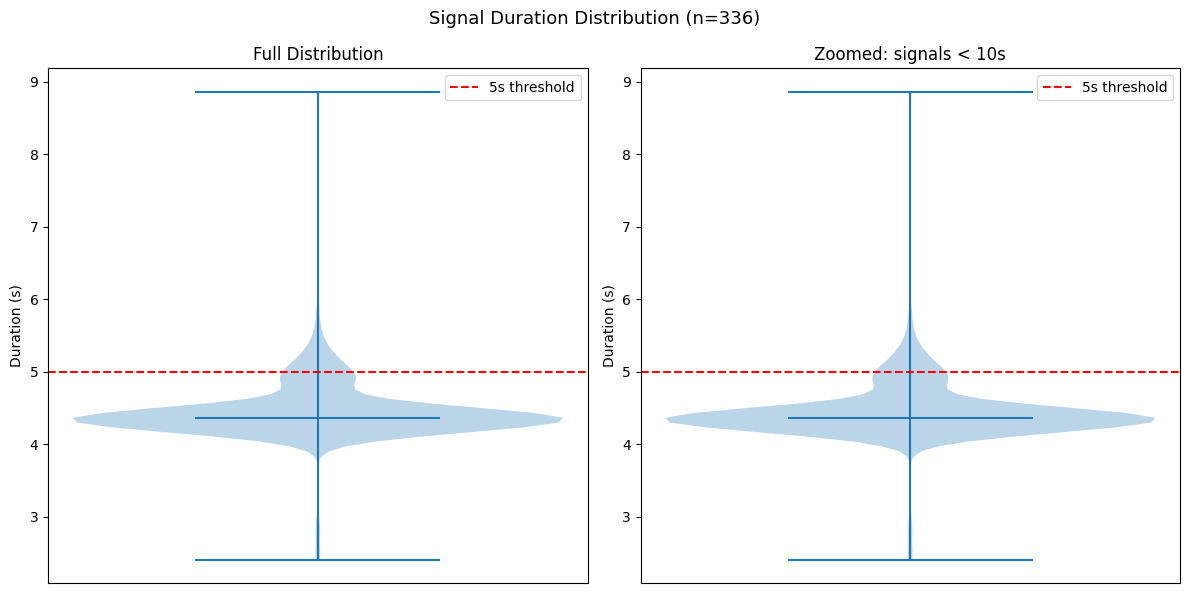

Saved: signal_duration_distribution.png


In [6]:
#@title Explore Signal Length Distribution
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path
from tqdm import tqdm

# 1. Collect durations
wav_files = list(Path(wav_folder).glob("*.wav"))
print(f"Found {len(wav_files)} files...")

durations = []
skipped = []

for f in tqdm(wav_files):
    try:
        y, _ = librosa.load(str(f), sr=sr)
        duration = len(y) / sr
        durations.append({'file': f.name, 'duration_s': duration})
    except Exception as e:
        skipped.append(f.name)
        print(f"Error loading {f.name}: {e}")

durations_s = np.array([d['duration_s'] for d in durations])

# 2. Summary stats
print(f"\n--- Duration Summary ---")
print(f"Total signals:     {len(durations_s)}")
print(f"Min:               {durations_s.min():.3f}s")
print(f"Max:               {durations_s.max():.3f}s")
print(f"Mean:              {durations_s.mean():.3f}s")
print(f"Median:            {np.median(durations_s):.3f}s")

# 3. Bucket breakdown
thresholds = [1, 2, 3, 4, 5]
print(f"\n--- Proportion by length ---")
for t in thresholds:
    n = np.sum(durations_s < t)
    print(f"  < {t}s : {n} signals ({100*n/len(durations_s):.1f}%)")
n_exact = np.sum(durations_s >= 5)
print(f"  >= 5s : {n_exact} signals ({100*n_exact/len(durations_s):.1f}%)")

# 4. Violin plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: full distribution violin
axes[0].violinplot(durations_s, showmedians=True, showextrema=True)
axes[0].axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='5s threshold')
axes[0].set_title('Full Distribution')
axes[0].set_ylabel('Duration (s)')
axes[0].set_xticks([])
axes[0].legend()

# Right: zoomed in on short signals (< 10s) to see the detail
short_mask = durations_s < 10
axes[1].violinplot(durations_s[short_mask], showmedians=True, showextrema=True)
axes[1].axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='5s threshold')
axes[1].set_title('Zoomed: signals < 10s')
axes[1].set_ylabel('Duration (s)')
axes[1].set_xticks([])
axes[1].legend()

plt.suptitle(f'Signal Duration Distribution (n={len(durations_s)})', fontsize=13)
plt.tight_layout()
plt.savefig('signal_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: signal_duration_distribution.png")

We cannot drop all signals < 5s as we would reamin with only 7% of the dataset. We will keep windows that contain at least 75% signal, so are at least 3.75 seconds long, and pad with silence from the wav file at the end of the file. 

In [7]:
threshold = 3.75
n_kept = np.sum(durations_s >= threshold)
n_dropped = np.sum(durations_s < threshold)
print(f"Kept (>= 3.75s):  {n_kept} signals ({100*n_kept/len(durations_s):.1f}%)")
print(f"Dropped (< 3.75s): {n_dropped} signals ({100*n_dropped/len(durations_s):.1f}%)")

Kept (>= 3.75s):  332 signals (98.8%)
Dropped (< 3.75s): 4 signals (1.2%)


Processing 336 files...


100%|██████████| 336/336 [00:01<00:00, 225.42it/s]



Kept:    332 windows
Dropped: 4 files ['dolphin_3.wav', 'dolphin_2.wav', 'dolphin_4.wav', 'dolphin_154.wav']


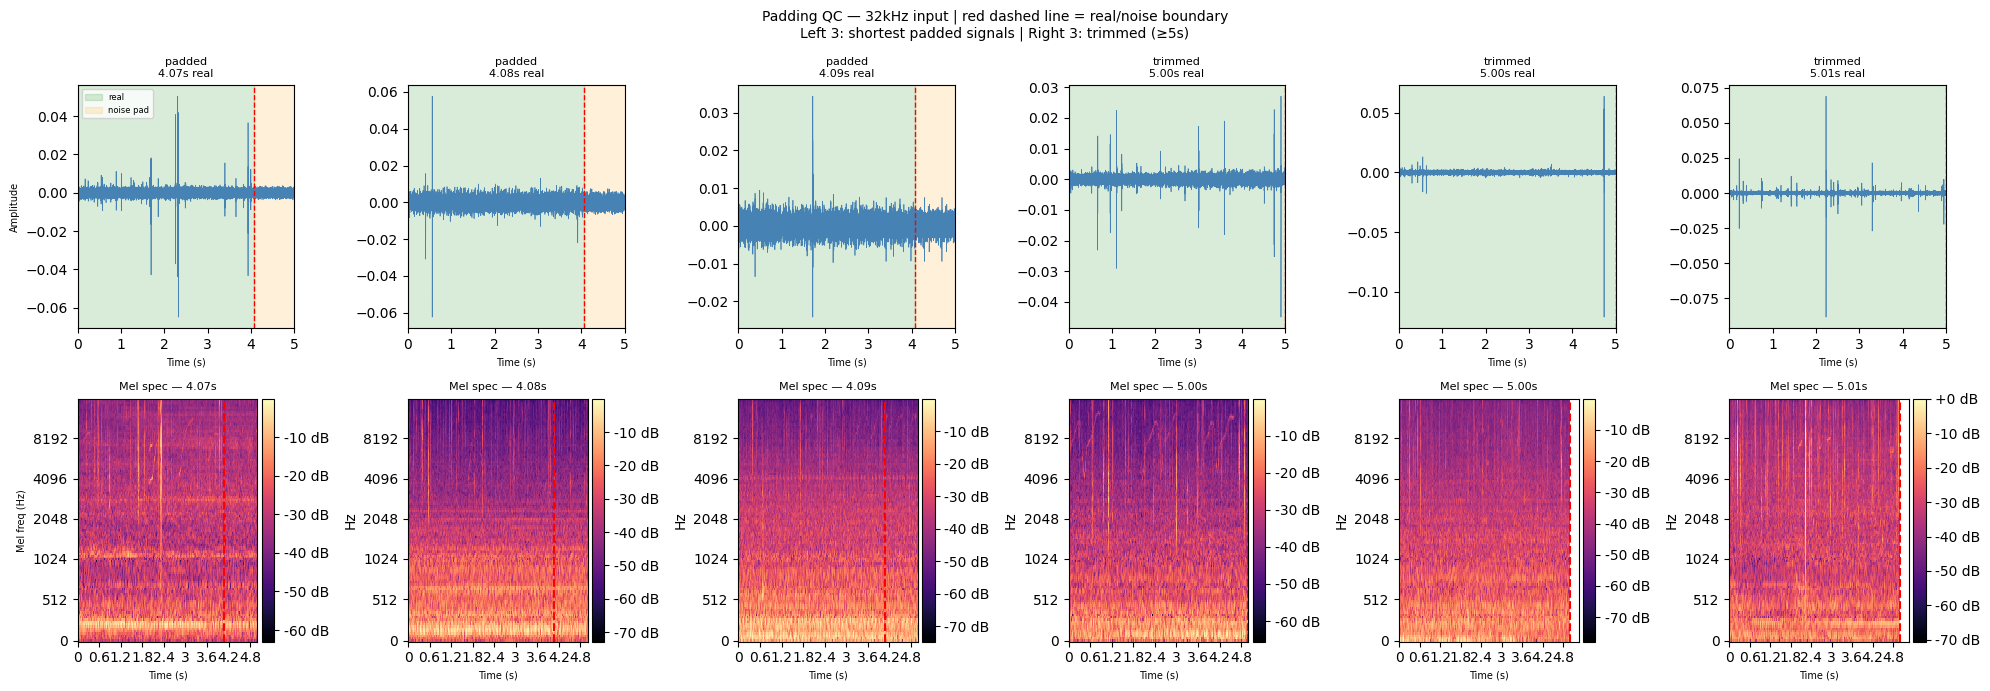

Saved: padding_qc_spectrograms.png


In [8]:
#@title Pad Short Signals with Background Noise + Spectrogram QC
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# ── Config ──────────────────────────────────────────────────────────────────
TARGET_SR     = 32000        # PERCHv2 expected sample rate
WINDOW_S      = 5.0          # target window length
MIN_REAL_RATIO = 0.75        # drop if signal < 75% of window
TARGET_SAMPLES = int(WINDOW_S * TARGET_SR)  # 160,000 samples

# ── Noise sampler ────────────────────────────────────────────────────────────
def sample_background_noise(signal, n_samples, noise_floor_percentile=10):
    """
    Estimate background noise from the quietest part of the signal itself.
    Takes the lowest-energy frames and uses them as noise template,
    then tiles/crops to exactly n_samples.
    """
    frame_len = TARGET_SR // 10  # 100ms frames
    frames = librosa.util.frame(signal, frame_length=frame_len, hop_length=frame_len)
    # energy per frame
    energies = np.mean(frames**2, axis=0)
    # keep only the quietest frames (noise floor)
    threshold = np.percentile(energies, noise_floor_percentile)
    quiet_frames = frames[:, energies <= threshold]
    
    if quiet_frames.shape[1] == 0:
        # fallback: use gaussian noise matched to signal std
        return np.random.normal(0, signal.std() * 0.1, n_samples).astype(np.float32)
    
    # flatten quiet frames into a noise template
    noise_template = quiet_frames.flatten(order='F')
    
    # tile to cover n_samples, then crop
    repeats = int(np.ceil(n_samples / len(noise_template)))
    noise = np.tile(noise_template, repeats)[:n_samples]
    return noise.astype(np.float32)


# ── Pad a single signal ───────────────────────────────────────────────────
def pad_to_window(signal, target_samples=TARGET_SAMPLES):
    """
    Pad signal to target_samples by appending background noise estimated
    from the signal's own noise floor.
    """
    n_pad = target_samples - len(signal)
    if n_pad <= 0:
        return signal[:target_samples]
    noise_pad = sample_background_noise(signal, n_pad)
    return np.concatenate([signal, noise_pad])


# ── Process all files ─────────────────────────────────────────────────────
wav_files = list(Path(wav_folder).glob("*.wav"))
windows_data = []
dropped = []

print(f"Processing {len(wav_files)} files...")
for f in tqdm(wav_files):
    try:
        y, _ = librosa.load(str(f), sr=TARGET_SR)
        duration = len(y) / TARGET_SR

        # Drop if below 75% threshold
        if duration < (WINDOW_S * MIN_REAL_RATIO):
            dropped.append(f.name)
            continue

        # Case 1: shorter than window → pad
        if len(y) < TARGET_SAMPLES:
            audio_out = pad_to_window(y)
            strategy = 'padded'

        # Case 2: exactly 5s or longer → chunk into 5s windows
        else:
            audio_out = y[:TARGET_SAMPLES]   # first chunk; extend if needed
            strategy = 'trimmed'

        windows_data.append({
            'file':     f.name,
            'audio':    audio_out,
            'duration_original_s': round(duration, 3),
            'strategy': strategy,
            'label':    'Tursiops_truncatus'
        })

    except Exception as e:
        print(f"  Error {f.name}: {e}")

print(f"\nKept:    {len(windows_data)} windows")
print(f"Dropped: {len(dropped)} files {dropped}")


# ── Spectrogram QC ────────────────────────────────────────────────────────
# Show 6 examples: 3 padded (shortest signals) + 3 trimmed (longest)
padded_examples  = [w for w in windows_data if w['strategy'] == 'padded']
trimmed_examples = [w for w in windows_data if w['strategy'] == 'trimmed']

# sort padded by shortest original duration to stress-test the padding
padded_examples  = sorted(padded_examples,  key=lambda x: x['duration_original_s'])[:3]
trimmed_examples = sorted(trimmed_examples, key=lambda x: x['duration_original_s'])[:3]
examples = padded_examples + trimmed_examples

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for col, w in enumerate(examples):
    audio = w['audio']
    dur   = w['duration_original_s']
    strat = w['strategy']

    # ── Waveform (top row) ──
    ax_wave = axes[0][col]
    times = np.linspace(0, WINDOW_S, len(audio))
    ax_wave.plot(times, audio, linewidth=0.5, color='steelblue')

    # shade the real signal vs padded region
    real_end = dur
    ax_wave.axvspan(0,        real_end,  alpha=0.15, color='green',  label='real')
    ax_wave.axvspan(real_end, WINDOW_S,  alpha=0.15, color='orange', label='noise pad')
    ax_wave.axvline(real_end, color='red', linewidth=1, linestyle='--')
    ax_wave.set_xlim(0, WINDOW_S)
    ax_wave.set_title(f"{strat}\n{dur:.2f}s real", fontsize=8)
    ax_wave.set_xlabel("Time (s)", fontsize=7)
    if col == 0:
        ax_wave.set_ylabel("Amplitude", fontsize=7)
        ax_wave.legend(fontsize=6)

    # ── Mel spectrogram (bottom row) ──
    ax_spec = axes[1][col]
    S = librosa.feature.melspectrogram(
        y=audio,
        sr=TARGET_SR,
        n_mels=128,
        fmin=0,
        fmax=TARGET_SR // 2,   # 16 kHz max for 32kHz input
        hop_length=160,        # 5ms hop → good time resolution
        n_fft=1024
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(
        S_db,
        sr=TARGET_SR,
        hop_length=160,
        fmin=0,
        fmax=TARGET_SR // 2,
        x_axis='time',
        y_axis='mel',
        ax=ax_spec,
        cmap='magma'
    )
    ax_spec.axvline(real_end, color='red', linewidth=1.5, linestyle='--', label='pad start')
    ax_spec.set_title(f"Mel spec — {dur:.2f}s", fontsize=8)
    ax_spec.set_xlabel("Time (s)", fontsize=7)
    if col == 0:
        ax_spec.set_ylabel("Mel freq (Hz)", fontsize=7)
    fig.colorbar(img, ax=ax_spec, format='%+2.0f dB', pad=0.02)

plt.suptitle(
    f"Padding QC — 32kHz input | red dashed line = real/noise boundary\n"
    f"Left 3: shortest padded signals | Right 3: trimmed (≥5s)",
    fontsize=10
)
plt.tight_layout()
plt.savefig('padding_qc_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: padding_qc_spectrograms.png")

In [9]:
#@title Extract Embeddings from Padded Windows
import numpy as np
from tqdm import tqdm

# Reset lists
embeddings_list, logits_list, labels_list, failed_files = [], [], [], []

print(f"Processing {len(windows_data)} padded windows...")

for i, w in enumerate(tqdm(windows_data)):
    try:
        audio = w['audio'].astype(np.float32)  # already 5s @ 32kHz from padding step

        # Run through PERCHv2
        out = embedding_model.embed(audio)

        # Mean-pool embeddings across time axis
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(w['label'])

    except Exception as e:
        failed_files.append(w['file'])
        print(f"  FAILED [{w['file']}] — {repr(e)}")

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(windows_data)} embedded...")

# Final stack
X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f"\nDone. {len(X)} embedded, {len(failed_files)} failed.")
print(f"Embedding shape:  {X.shape}")
print(f"Logits shape:     {Z.shape}")

Processing 332 padded windows...


  0%|          | 0/332 [00:00<?, ?it/s]2026-04-29 08:15:32.224878: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f5b2806dca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-29 08:15:32.224925: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-04-29 08:15:32.562670: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-29 08:15:32.610859: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92100
2026-04-29 08:15:33.542526: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 68 bytes spill stores, 68 bytes spill loads

2026-04-29 08:15:33.818746: I external/local_xla/xla/stream_executor/cuda/subprocess_com

  100/332 embedded...


 63%|██████▎   | 210/332 [00:16<00:02, 52.46it/s]

  200/332 embedded...


 92%|█████████▏| 306/332 [00:18<00:00, 52.74it/s]

  300/332 embedded...


100%|██████████| 332/332 [00:19<00:00, 17.42it/s]


Done. 332 embedded, 0 failed.
Embedding shape:  (332, 1536)
Logits shape:     (332, 14795)


In [10]:
#@title Save embeddings and metadata to Drive (Concatenated Version)
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Create necessary directories
os.makedirs(f'{save_dir}/embeddings', exist_ok=True)

# --- Build dummy metadata for concatenated windows ---
# Since we didn't use a windows_df, we create a metadata shell to maintain notebook logic
rows = []
for idx in range(len(X)):
    rows.append({
        'wav_path': 'concatenated_stream',
        'offset_s': idx * window_size_s,
        'label': y[idx],
        'embedding_idx': idx
    })

metadata_df = pd.DataFrame(rows)

# --- NaN diagnostic ---
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any = nan_in_X | nan_in_Z

print('=== NaN DIAGNOSTIC ===')
print(f'Total windows:          {len(X)}')
print(f'Rows with NaN in X:     {nan_in_X.sum()}')
print(f'Rows with NaN in Z:     {nan_in_Z.sum()}')
print(f'Rows with NaN in either:{nan_any.sum()}')

if nan_any.sum() > 0:
    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'\n{nan_any.sum()} NaN rows ({pct:.2f}% of data) — dropping.')
        valid = ~nan_any
        X_save = X[valid]
        Z_save = Z[valid]
        y_save = y[valid]
        metadata_save = metadata_df[valid].reset_index(drop=True)
        metadata_save['embedding_idx'] = metadata_save.index
    else:
        print(f'\nWARNING: {pct:.2f}% NaN — investigate stream quality.')
        X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df
else:
    print('\nNo NaN values found — data is clean.')
    X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df

# --- Final Save ---
np.save(f'{save_dir}/embeddings/X_embeddings.npy', X_save)
np.save(f'{save_dir}/embeddings/Z_logits.npy', Z_save)
np.save(f'{save_dir}/embeddings/y_labels.npy', y_save)
metadata_save.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir}/embeddings ===')
print(f'  X_embeddings.npy  — {X_save.shape}')
print(f'  Z_logits.npy      — {Z_save.shape}')
print(f'  y_labels.npy      — {y_save.shape}')
print(f'  metadata.csv      — {len(metadata_save)} rows')
print(f'\nClass distribution in saved data:')
print(pd.Series(y_save).value_counts())

=== NaN DIAGNOSTIC ===
Total windows:          332
Rows with NaN in X:     0
Rows with NaN in Z:     0
Rows with NaN in either:0

No NaN values found — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/FREMANTLE/embeddings ===
  X_embeddings.npy  — (332, 1536)
  Z_logits.npy      — (332, 14795)
  y_labels.npy      — (332,)
  metadata.csv      — 332 rows

Class distribution in saved data:
Tursiops_truncatus    332
Name: count, dtype: int64


# retrieving the data and performing zero-shot classifications

In [11]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')   # (9209, 1536)
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   # (9209,)
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   # (9209,)

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (332, 1536), Z: (332, 14795), y: (332,)
Class distribution:
Tursiops_truncatus    332
Name: count, dtype: int64


In [14]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['dolphin', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphin', 'cetacea']):
        print(name)

print("\n--- Water/noise/background ---")
for name in perch_class_names:
    if any(term in name.lower() for term in ['water', 'noise', 'background', 'ambient', 'silence', 'rain', 'wave', 'ocean', 'sea']):
        print(name)

Colibri delphinae
Delphinapterus leucas
Myzomela adolphinae
Phylloscopus whistleri
Tursiops truncatus

--- Water/noise/background ---
Anstisia rosea
Anthus roseatus
Ardenna grisea
Boat_and_Water_vehicle
Cinnyris osea
Conocephalus oceanicus
Coracina caeruleogrisea
Ducula oceanica
Formicivora grisea
Gull_and_seagull
Lycalopex grisea
Microwave_oven
Myiagra oceanica
Myopsalta waterhousei
Myrmotherula grisea
Ocean
Oceanites gracilis
Oceanites oceanicus
Oceanites pincoyae
Petroica rosea
Platycleis grisea
Poecilimon ukrainicus
Prioniturus waterstradti
Psittacula roseata
Rain
Raindrop
Rhodinocichla rosea
Rhodostethia rosea
Sarothrura watersi
Streptopelia roseogrisea
Tachycineta euchrysea
Tamasa rainbowi
Teleogryllus oceanicus
Thalurania watertonii
Traffic_noise_and_roadway_noise
Train
Water
Water_tap_and_faucet
Waves_and_surf
Zoothera talaseae


In [12]:
#@title Zero-shot species analysis — what does Perch think your sounds are?


# Get the class names in order
class_names_list = list(embedding_model.class_list['labels'].classes)

# 2. FIX: Use the actual label or analyze the whole array
# Since this dataset is 100% signal, we don't need to filter for 'whistle'
Z_whistle = Z_clean 

# Mean logit per class across all windows
mean_logits_whistle = Z_whistle.mean(axis=0)

# Top 20 classes for whistles
top_whistle_idx = np.argsort(mean_logits_whistle)[::-1][:20]
print('TOP 20 PERCH CLASSES FOR YOUR DATA:')
print('-' * 50)
for idx in top_whistle_idx:
    print(f'  {mean_logits_whistle[idx]:6.3f}  {class_names_list[idx]}')

print()

# Classes to investigate
whistle_candidates = {
    'Tursiops truncatus': class_names_list.index('Tursiops truncatus'),
}

print('\nWHISTLE CANDIDATES — mean logit analysis:')
print('-' * 70)
for name, idx in whistle_candidates.items():
    w_logit = mean_logits_whistle[idx]
    # Calculate rank
    w_rank = np.where(np.argsort(mean_logits_whistle)[::-1] == idx)[0][0] + 1
    print(f'  {name:30s}  mean logit: {w_logit:6.3f} (Rank #{w_rank:d})')

TOP 20 PERCH CLASSES FOR YOUR DATA:
--------------------------------------------------
   5.848  Domestic_sounds_and_home_sounds
   5.733  Sturnus vulgaris
   5.624  Water
   5.553  Rain
   5.499  Fire
   5.345  Vehicle
   5.296  Crackle
   5.287  Animal
   5.119  Cardinalis cardinalis
   5.067  Mechanisms
   4.994  Strix varia
   4.984  Phylloscopus collybita
   4.922  Molothrus ater
   4.908  Engine
   4.847  Baeolophus bicolor
   4.812  Parus major
   4.769  Bubo virginianus
   4.590  Erithacus rubecula
   4.588  Melospiza melodia
   4.582  Turdus migratorius


WHISTLE CANDIDATES — mean logit analysis:
----------------------------------------------------------------------
  Tursiops truncatus              mean logit: -2.026 (Rank #11060)


Running full PCA...


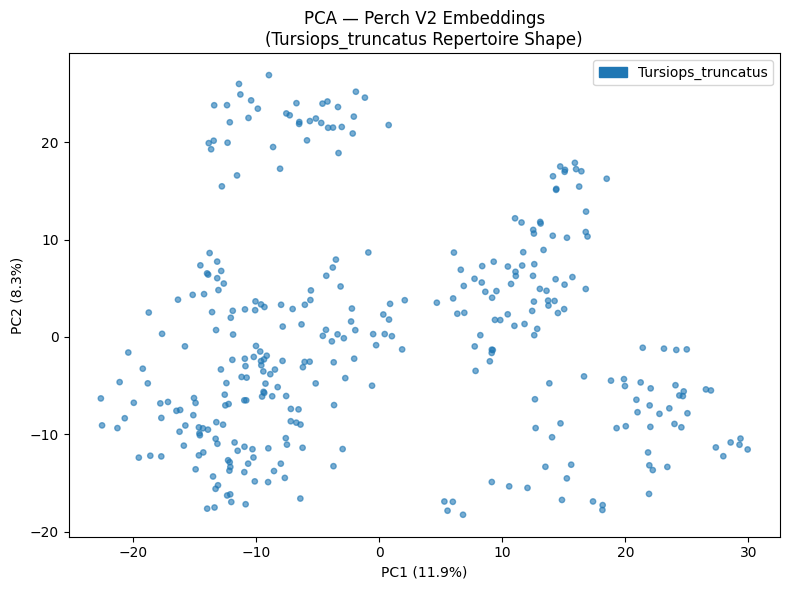


Running t-SNE...


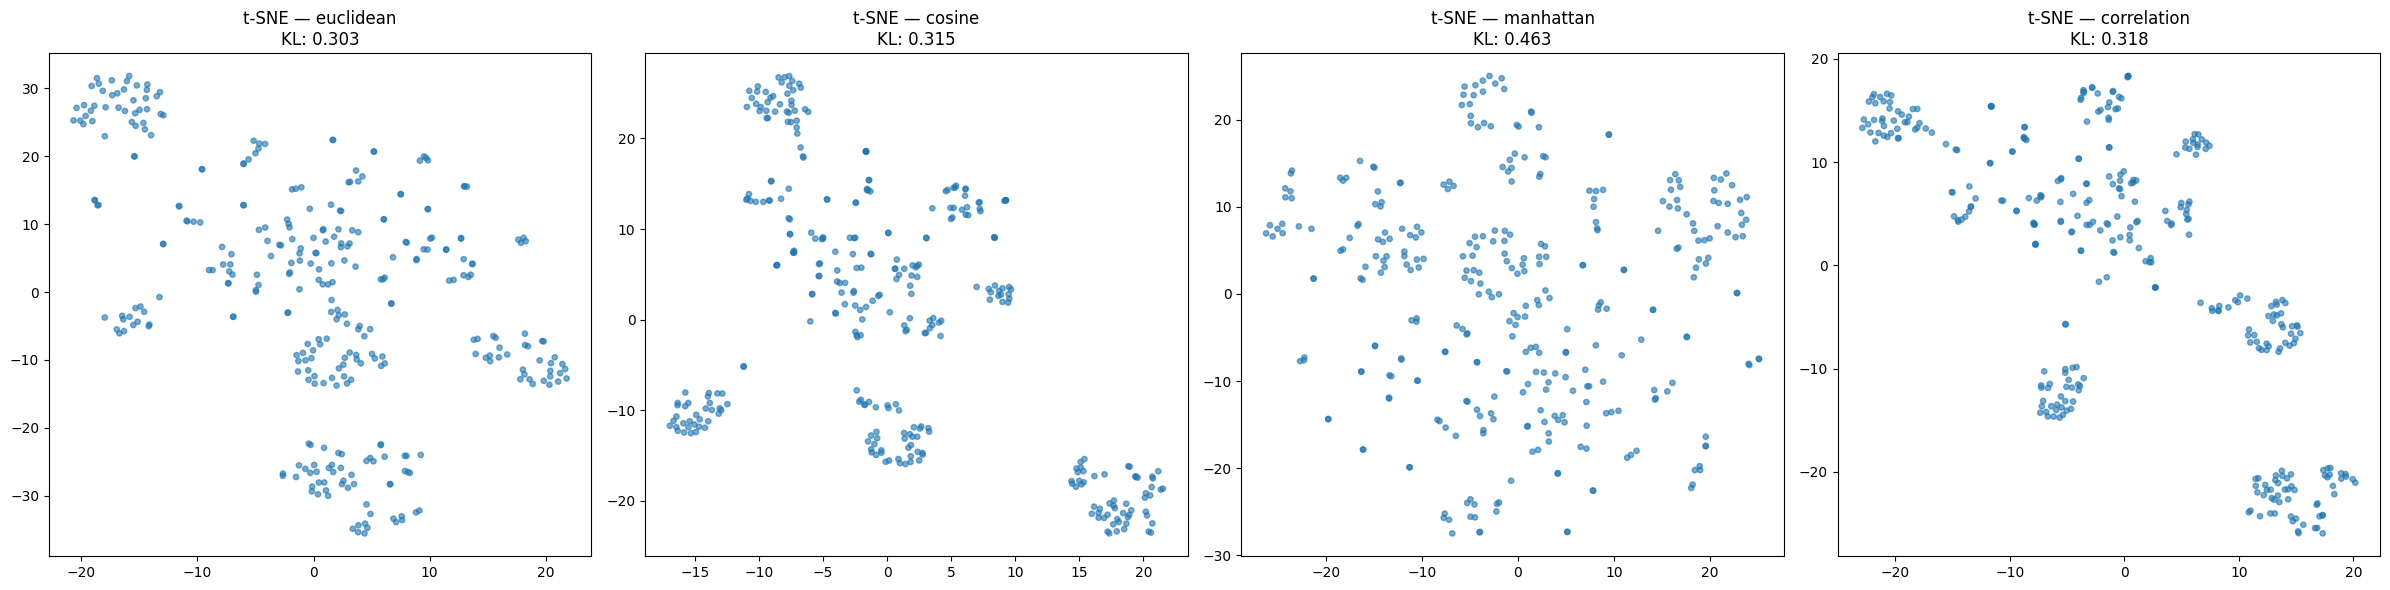


Running UMAP...


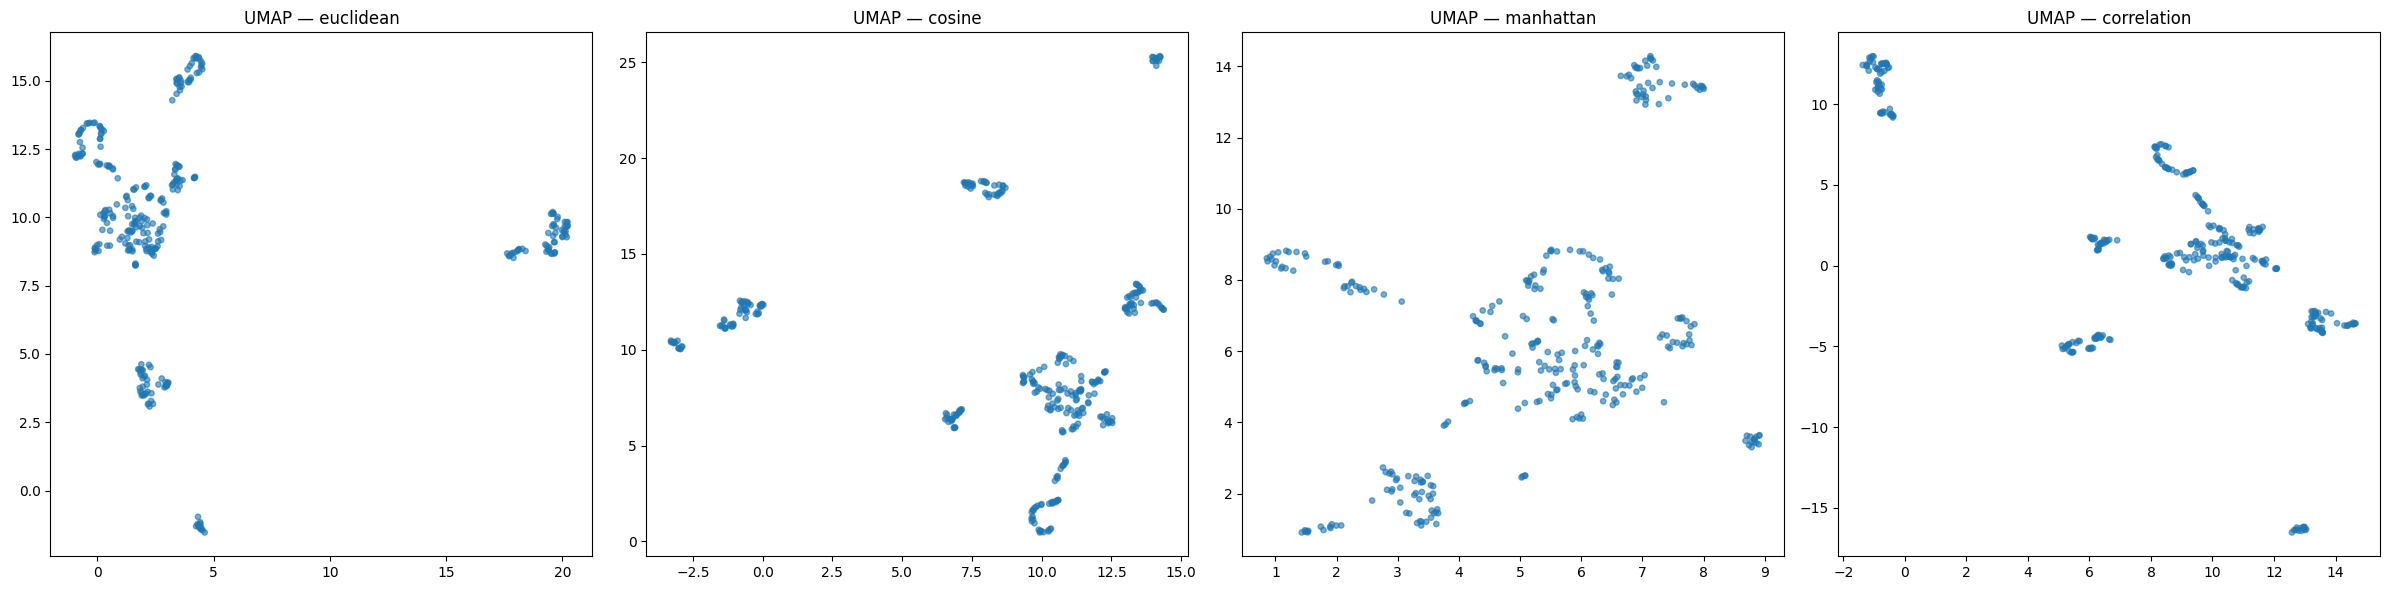


Done. Visualizations saved to /data2/mromaniuc/cet-det/models/perch_v2/FREMANTLE/dim_red


In [13]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (Fremantle Tursiops)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Prepare data (Ensure these are assigned from your save variables)
X_clean = X_save
y_clean = y_save

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup — Dynamic mapping for whatever labels are in y_clean
unique_labels = sorted(np.unique(y_clean))
tab_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
colors_map = {label: tab_colors[i] for i, label in enumerate(unique_labels)}
c = np.array([colors_map[label] for label in y_clean])
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]

alpha = 0.6
s = 15

# Ensure directory exists
os.makedirs(f'{save_dir}/dim_red', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. PCA — Variance Analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

n90 = np.argmax(cumvar_full >= 90) + 1
n_pca = n90 # Use 90% variance for t-SNE/UMAP input

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'PCA — Perch V2 Embeddings\n({y_clean[0]} Repertoire Shape)')
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d_fremantle.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. t-SNE & UMAP (Multi-metric Comparison)
# ═══════════════════════════════════════════════════════════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)

metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

# --- t-SNE ---
print('\nRunning t-SNE...')
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    tsne = TSNE(n_components=2, perplexity=30, metric=metric, random_state=random_seed)
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL: {tsne.kl_divergence_:.3f}')

plt.tight_layout()
plt.show()

# --- UMAP ---
print('\nRunning UMAP...')
import umap
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
umap_results = {}

for ax, metric in zip(axes, metrics):
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric=metric, random_state=random_seed)
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap
    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')

plt.tight_layout()
plt.show()

print(f'\nDone. Visualizations saved to {save_dir}/dim_red')